# AquaSmart — Exploratory Data Analysis (EDA)

**Sprint 1 | Notebook 01**

This notebook explores the AquaSmart dataset collected from official sources:
- **Open-Meteo Historical API** — daily weather, ET0, soil moisture (2020-2024)
- **FAO-56 Kc coefficients** — winter wheat crop water demand
- **5 locations** in the Beauce region (France)

**Target variable:** `water_need_index` (mm/day) = max(0, ET0 x Kc - effective_rainfall)

**Objectives:**
1. Understand the dataset structure and quality
2. Analyze feature distributions and detect anomalies
3. Explore correlations and feature-target relationships
4. Identify preprocessing decisions for modeling

## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100, 'font.size': 12})

COLORS = {
    'primary': '#1D9E75', 'secondary': '#378ADD', 'warning': '#EF9F27',
    'danger': '#E24B4A', 'purple': '#534AB7', 'coral': '#D85A30', 'gray': '#888780',
}
print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('../data/raw/aquasmart_raw.csv')
df['date'] = pd.to_datetime(df['date'])

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Locations: {df["location"].nunique()} -- {", ".join(df["location"].unique())}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

Dataset shape: 9135 rows x 23 columns
Date range: 2020-01-01 to 2024-12-31
Locations: 5 -- Chartres, Orleans, Pithiviers, Chateaudun, Etampes
Memory: 2.6 MB


## 2. Data quality assessment

Before any analysis, we verify data integrity: missing values, duplicates, data types, and anomalies.

In [3]:
print('=' * 70)
print('COLUMN INVENTORY')
print('=' * 70)
for col in df.columns:
    dtype = str(df[col].dtype)
    nulls = df[col].isnull().sum()
    unique = df[col].nunique()
    status = 'OK' if nulls == 0 else f'{nulls} missing ({nulls/len(df)*100:.1f}%)'
    print(f'  {col:40s} {dtype:10s} | {unique:5d} unique | {status}')

print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'Total missing cells: {df.isnull().sum().sum()}')

COLUMN INVENTORY
  date                                     datetime64[ns] |  1827 unique | OK
  temperature_2m_mean                      float64    |   331 unique | OK
  temperature_2m_max                       float64    |   380 unique | OK
  temperature_2m_min                       float64    |   286 unique | OK
  relative_humidity_2m_mean                int64      |    71 unique | OK
  precipitation_sum                        float64    |   251 unique | OK
  rain_sum                                 float64    |   251 unique | OK
  et0_fao_evapotranspiration               float64    |   719 unique | OK
  shortwave_radiation_sum                  float64    |  2681 unique | OK
  wind_speed_10m_max                       float64    |   428 unique | OK
  sunshine_duration                        float64    |  7770 unique | OK
  soil_moisture_0_to_7cm_mean              float64    |   313 unique | OK
  soil_moisture_7_to_28cm_mean             float64    |   301 unique | OK
  soil_moisture_2

In [4]:
df.select_dtypes(include=[np.number]).describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
temperature_2m_mean,9135.0,12.343,6.338,-4.200,7.700,12.100,17.400,29.900
temperature_2m_max,9135.0,16.424,7.253,-2.300,10.900,16.100,21.900,38.300
temperature_2m_min,9135.0,8.360,5.696,-6.800,4.200,8.400,12.900,23.200
relative_humidity_2m_mean,9135.0,76.594,12.099,28.000,69.000,78.000,86.000,98.000
precipitation_sum,9135.0,2.103,4.115,0.000,0.000,0.300,2.400,65.500
rain_sum,9135.0,2.071,4.087,0.000,0.000,0.200,2.300,65.500
et0_fao_evapotranspiration,9135.0,2.358,1.697,0.150,0.850,2.030,3.520,9.280
shortwave_radiation_sum,9135.0,12.528,8.139,0.570,4.965,11.550,19.390,29.930
wind_speed_10m_max,9135.0,20.743,7.876,5.600,14.900,19.500,25.400,54.800
sunshine_duration,9135.0,28713.362,16880.998,0.000,15027.600,30012.540,43200.000,57205.070


**Observations:**
- **Zero missing values** across all 23 columns — the Open-Meteo API returns complete daily records.
- **No duplicates** — each row is a unique (date, location) pair.
- Note: SoilGrids static properties are missing (API temporarily unavailable). These will be added later.

Although there are no missing values to impute, the data still requires feature engineering decisions which we identify through this EDA.

## 3. Target variable analysis: Water Need Index

The Water Need Index (mm/day) is computed using the FAO method:

**WNI = max(0, ET0 x Kc - 0.8 x rainfall)**

Where:
- **ET0** = reference evapotranspiration (Open-Meteo, Penman-Monteith)
- **Kc** = crop coefficient (FAO-56 tables, winter wheat)
- **0.8 x rainfall** = effective rainfall (simplified USDA-SCS method)

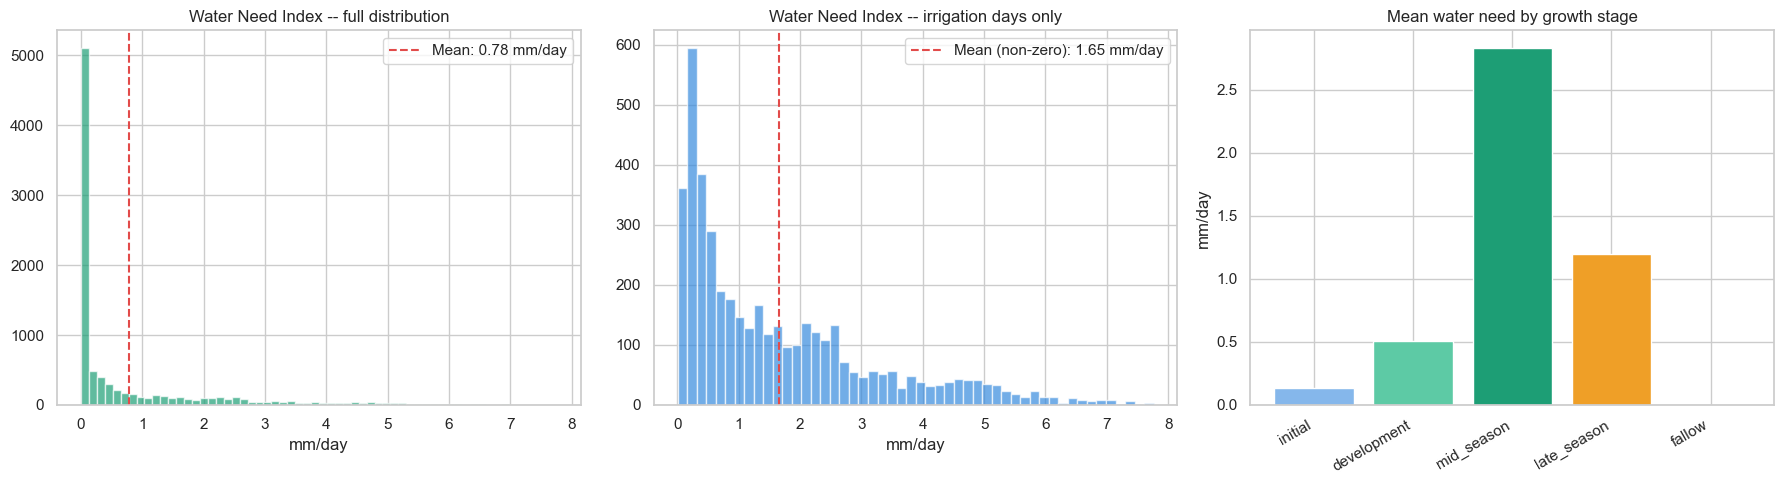

Zero values: 4839 (53.0%) -- fallow periods + rainy days
Non-zero: 4296 (47.0%) -- actual irrigation demand
Non-zero stats: mean=1.65, median=1.11, max=7.76


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full distribution
axes[0].hist(df['water_need_index'], bins=60, color=COLORS['primary'], alpha=0.7, edgecolor='white')
axes[0].axvline(df['water_need_index'].mean(), color=COLORS['danger'], linestyle='--',
                label=f'Mean: {df["water_need_index"].mean():.2f} mm/day')
axes[0].set_title('Water Need Index -- full distribution')
axes[0].set_xlabel('mm/day')
axes[0].legend()

# Non-zero only
wni_pos = df[df['water_need_index'] > 0]['water_need_index']
axes[1].hist(wni_pos, bins=50, color=COLORS['secondary'], alpha=0.7, edgecolor='white')
axes[1].axvline(wni_pos.mean(), color=COLORS['danger'], linestyle='--',
                label=f'Mean (non-zero): {wni_pos.mean():.2f} mm/day')
axes[1].set_title('Water Need Index -- irrigation days only')
axes[1].set_xlabel('mm/day')
axes[1].legend()

# By growth stage
stage_order = ['initial', 'development', 'mid_season', 'late_season', 'fallow']
stage_means = df.groupby('growth_stage')['water_need_index'].mean().reindex(stage_order)
stage_colors = ['#85B7EB', '#5DCAA5', '#1D9E75', '#EF9F27', '#B4B2A9']
axes[2].bar(range(len(stage_means)), stage_means.values, color=stage_colors, edgecolor='white')
axes[2].set_xticks(range(len(stage_means)))
axes[2].set_xticklabels(stage_order, rotation=30, ha='right')
axes[2].set_title('Mean water need by growth stage')
axes[2].set_ylabel('mm/day')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

total = len(df)
zeros = (df['water_need_index'] == 0).sum()
print(f'Zero values: {zeros} ({zeros/total*100:.1f}%) -- fallow periods + rainy days')
print(f'Non-zero: {total - zeros} ({(total-zeros)/total*100:.1f}%) -- actual irrigation demand')
print(f'Non-zero stats: mean={wni_pos.mean():.2f}, median={wni_pos.median():.2f}, max={wni_pos.max():.2f}')

**Key findings:**

1. **Zero-inflated distribution**: 53% of values are zero because of fallow periods (Kc=0) and rainy days where rainfall exceeds crop demand.

2. **Mid-season peak**: Highest water demand in April-May (~3 mm/day), during heading/flowering when canopy is fullest.

3. **Modeling implication**: A standard regression trained on all data would be biased toward zeros. We will use a **two-stage approach**: first classify (irrigate or not?), then regress (how much?) on irrigation days only.

## 4. Temporal patterns

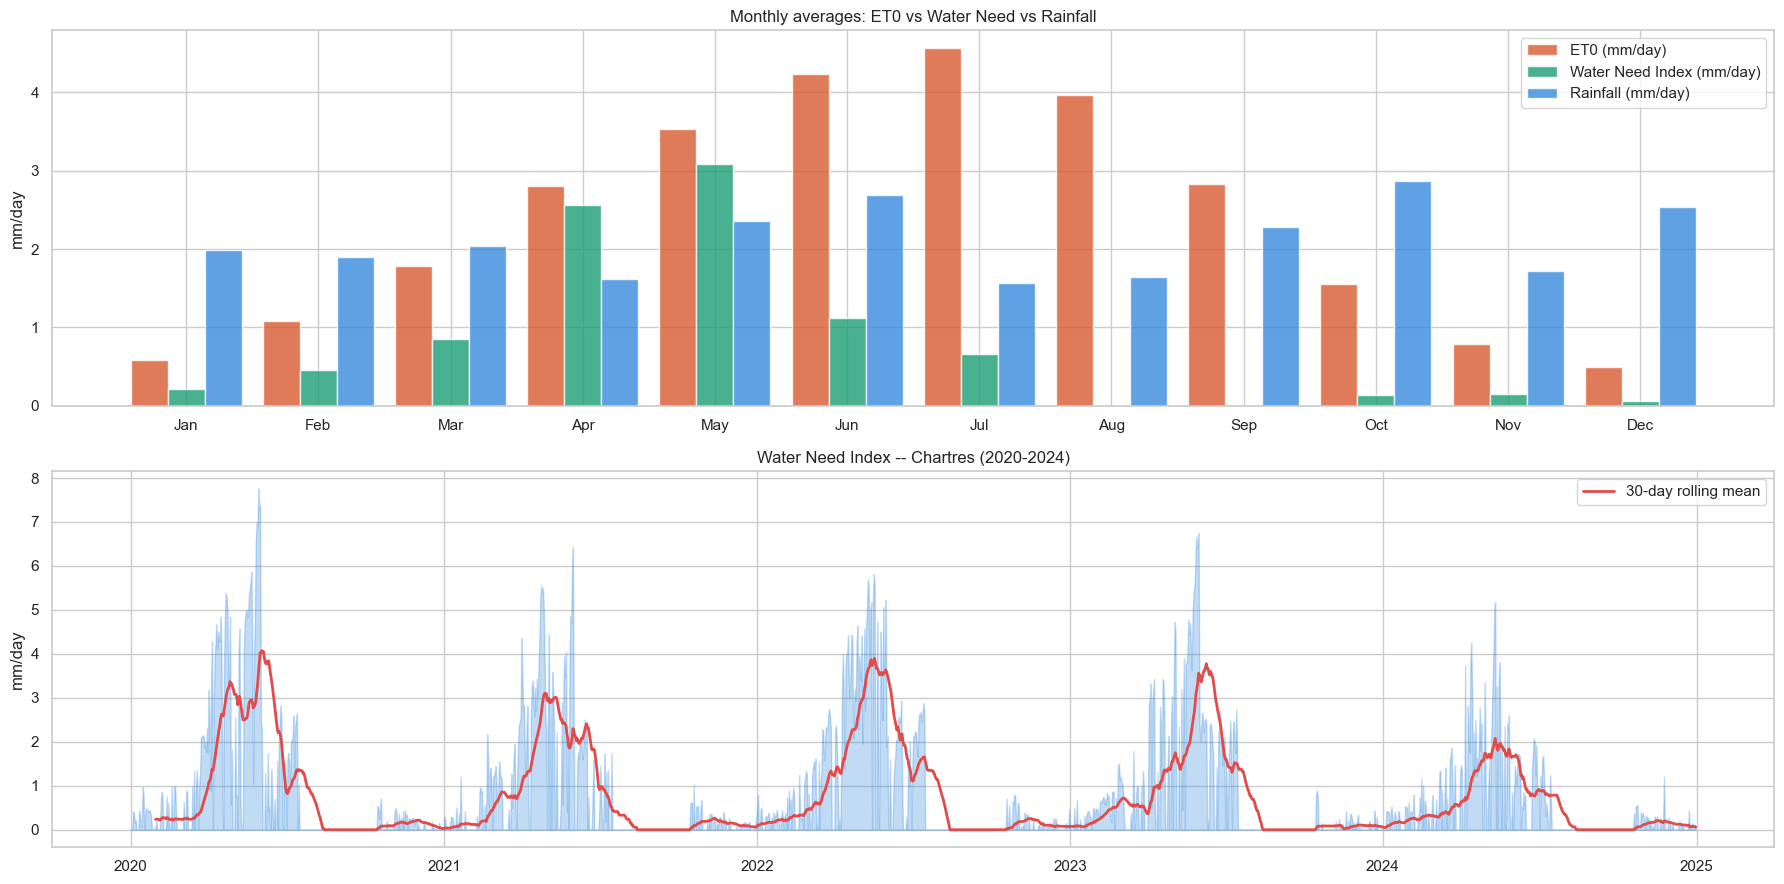

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9))

df['month'] = df['date'].dt.month
monthly = df.groupby('month').agg({
    'water_need_index': 'mean',
    'et0_fao_evapotranspiration': 'mean',
    'precipitation_sum': 'mean',
}).round(3)

x = np.arange(12)
width = 0.28
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

axes[0].bar(x - width, monthly['et0_fao_evapotranspiration'], width,
            label='ET0 (mm/day)', color=COLORS['coral'], alpha=0.8)
axes[0].bar(x, monthly['water_need_index'], width,
            label='Water Need Index (mm/day)', color=COLORS['primary'], alpha=0.8)
axes[0].bar(x + width, monthly['precipitation_sum'], width,
            label='Rainfall (mm/day)', color=COLORS['secondary'], alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(months)
axes[0].set_ylabel('mm/day')
axes[0].set_title('Monthly averages: ET0 vs Water Need vs Rainfall')
axes[0].legend()

chartres = df[df['location'] == 'Chartres'].set_index('date')
axes[1].fill_between(chartres.index, chartres['water_need_index'], alpha=0.3, color=COLORS['secondary'])
axes[1].plot(chartres.index, chartres['water_need_index'].rolling(30).mean(),
             color=COLORS['danger'], linewidth=2, label='30-day rolling mean')
axes[1].set_title('Water Need Index -- Chartres (2020-2024)')
axes[1].set_ylabel('mm/day')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/02_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **Clear seasonal cycle**: demand peaks April-May, drops to zero August-September.
- **Summer ET0 is high but WNI is zero**: no crop in field (fallow, Kc=0). Confirms FAO calculation works correctly.
- **Rainfall partially offsets demand**: spring rainfall (~2 mm/day) covers part of the ~3.5 mm/day ET0.
- **Inter-annual variability**: 2022 shows higher peaks, consistent with the severe drought in France that year.

## 5. Feature distributions

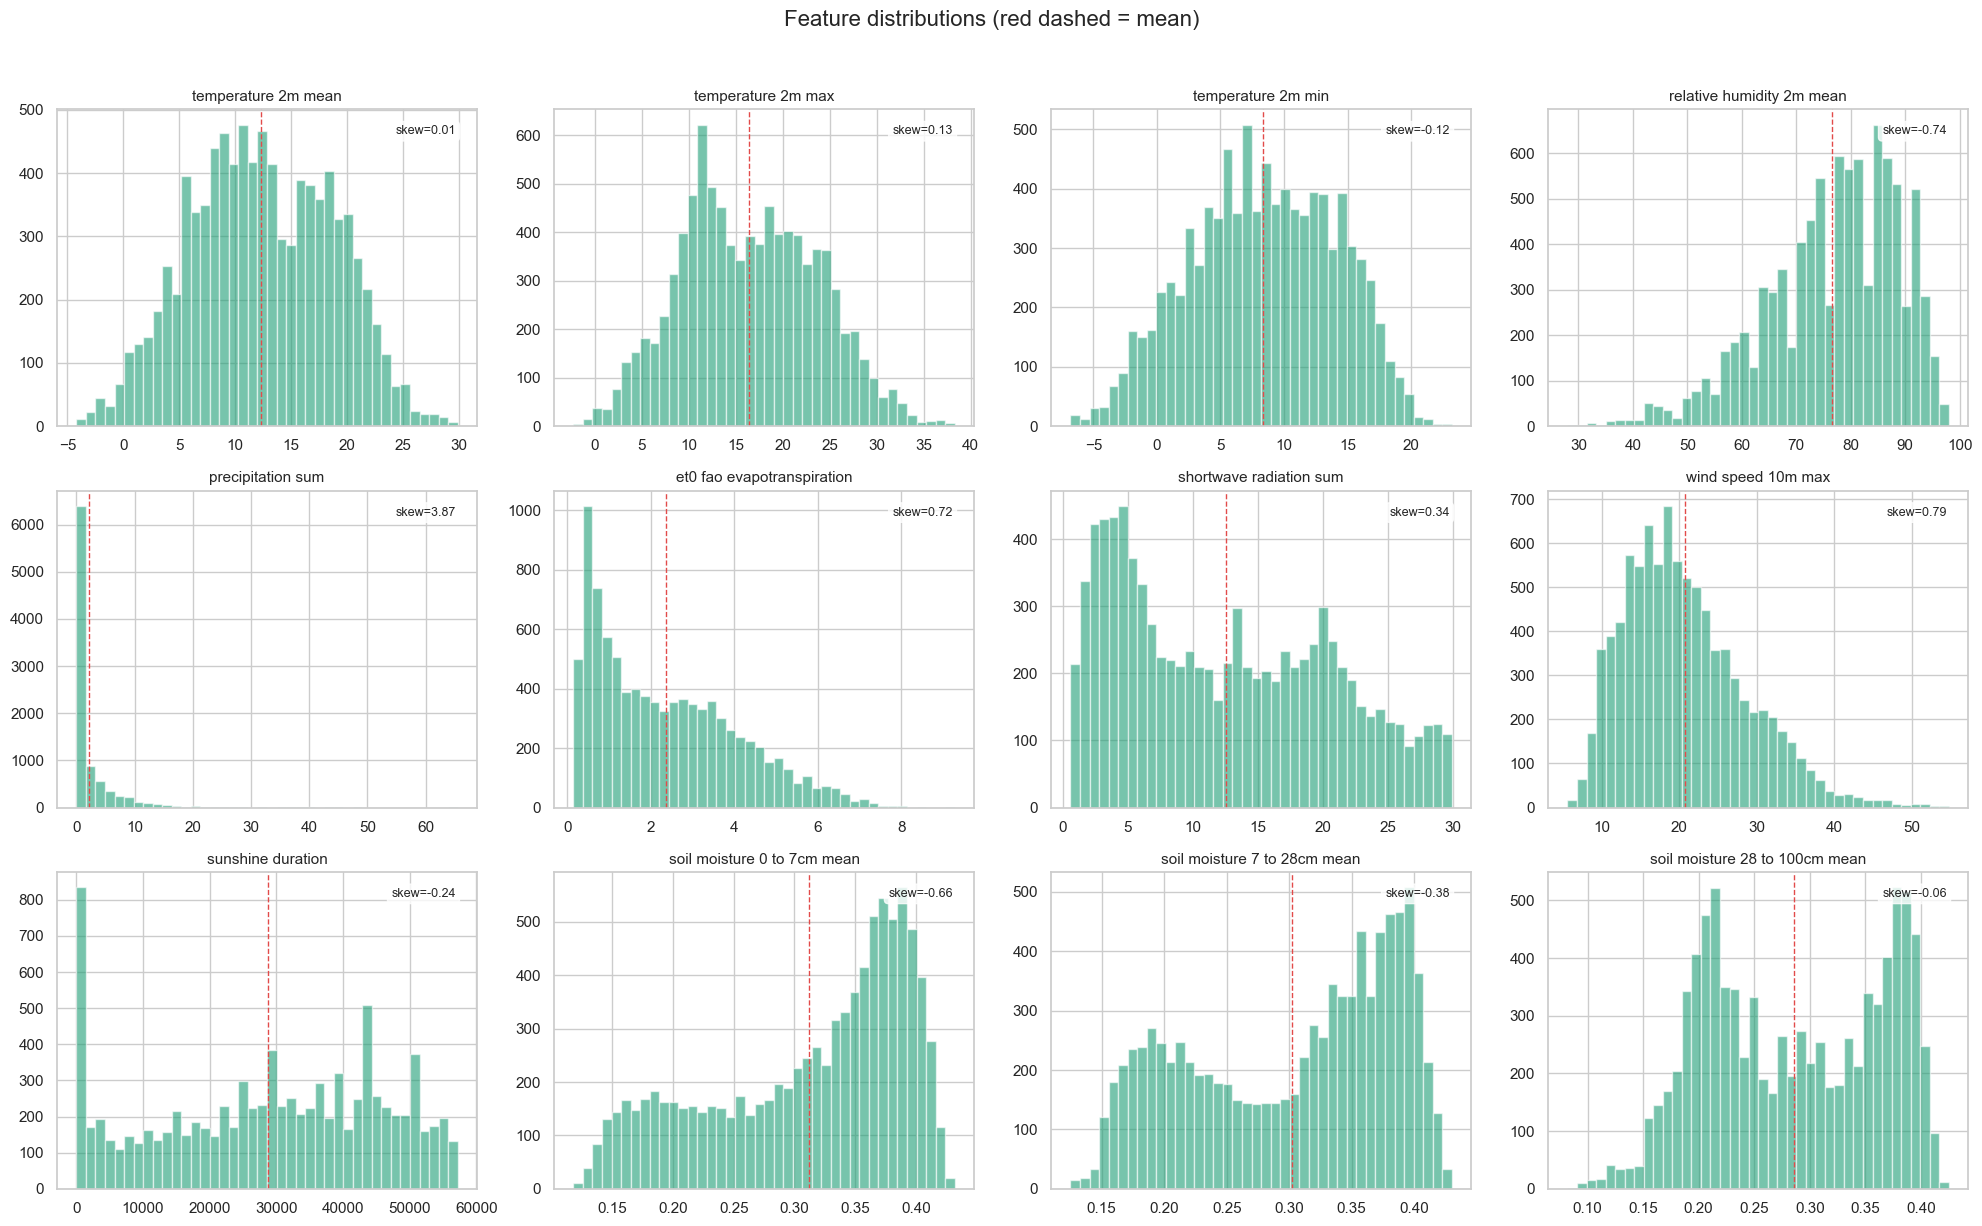

In [7]:
weather_features = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'relative_humidity_2m_mean', 'precipitation_sum',
    'et0_fao_evapotranspiration', 'shortwave_radiation_sum',
    'wind_speed_10m_max', 'sunshine_duration',
    'soil_moisture_0_to_7cm_mean', 'soil_moisture_7_to_28cm_mean',
    'soil_moisture_28_to_100cm_mean',
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(weather_features):
    ax = axes[i]
    ax.hist(df[col], bins=40, color=COLORS['primary'], alpha=0.6, edgecolor='white')
    ax.axvline(df[col].mean(), color=COLORS['danger'], linestyle='--', linewidth=1)
    ax.set_title(col.replace('_', ' '), fontsize=11)
    skew = df[col].skew()
    ax.text(0.95, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Feature distributions (red dashed = mean)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **Temperature**: roughly normal around 12C, range -4C to 30C (full annual cycle).
- **Precipitation**: heavily right-skewed (skew ~ 4.3) — most days have little rain, occasional heavy events up to 65 mm.
- **ET0**: right-skewed, concentrated 0-3 mm/day in winter, up to 8-9 mm/day in summer.
- **Soil moisture**: all three layers show similar distributions. Surface (0-7cm) is most variable.
- **No obvious outliers or data errors** — all values within physically plausible ranges.

## 6. Correlation analysis

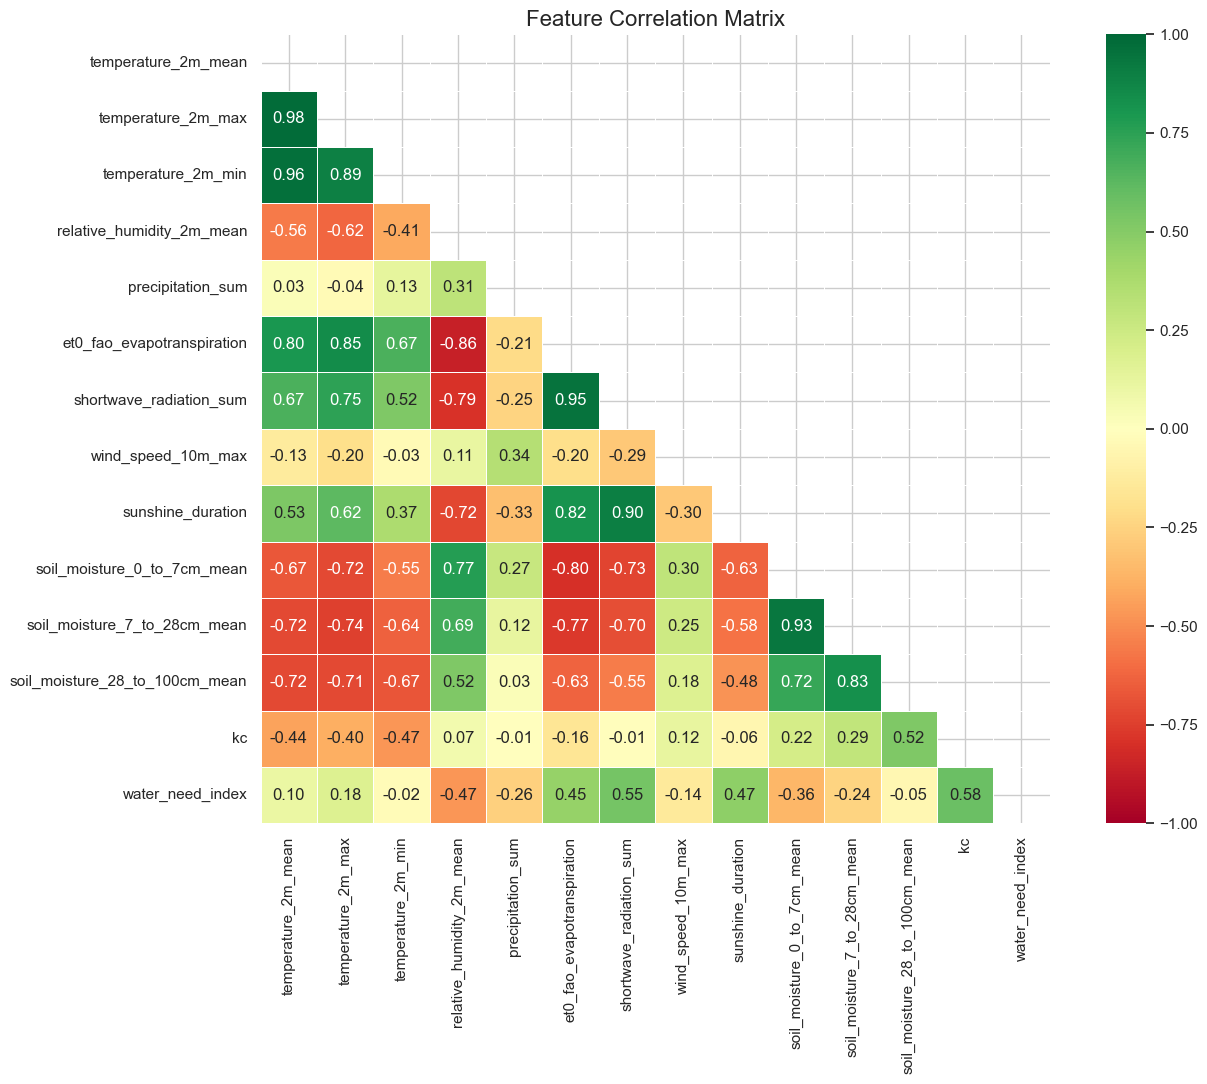

In [8]:
feature_cols = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'relative_humidity_2m_mean', 'precipitation_sum',
    'et0_fao_evapotranspiration', 'shortwave_radiation_sum',
    'wind_speed_10m_max', 'sunshine_duration',
    'soil_moisture_0_to_7cm_mean', 'soil_moisture_7_to_28cm_mean',
    'soil_moisture_28_to_100cm_mean', 'kc', 'water_need_index'
]

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', center=0,
            cmap='RdYlGn', ax=ax, square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('=' * 55)
print('CORRELATIONS WITH WATER NEED INDEX')
print('=' * 55)
target_corr = df[feature_cols].corr()['water_need_index'].drop('water_need_index')
for feat in target_corr.abs().sort_values(ascending=False).index:
    val = target_corr[feat]
    bar_len = int(abs(val) * 30)
    bar = '#' * bar_len
    direction = '+' if val > 0 else '-'
    flag = ' << KEY' if abs(val) > 0.3 else ''
    print(f'  {feat:40s} {direction}{abs(val):.3f} {bar}{flag}')

CORRELATIONS WITH WATER NEED INDEX
  kc                                       +0.583 ################# << KEY
  shortwave_radiation_sum                  +0.547 ################ << KEY
  relative_humidity_2m_mean                -0.471 ############## << KEY
  sunshine_duration                        +0.469 ############## << KEY
  et0_fao_evapotranspiration               +0.448 ############# << KEY
  soil_moisture_0_to_7cm_mean              -0.360 ########## << KEY
  precipitation_sum                        -0.263 #######
  soil_moisture_7_to_28cm_mean             -0.244 #######
  temperature_2m_max                       +0.178 #####
  wind_speed_10m_max                       -0.140 ####
  temperature_2m_mean                      +0.103 ###
  soil_moisture_28_to_100cm_mean           -0.053 #
  temperature_2m_min                       -0.024 


**Key correlation findings:**

**Strong positive correlations with water need:**
- `kc` (+0.58): Growth stage is the primary driver.
- `shortwave_radiation_sum` (+0.55): More sun = more evapotranspiration.
- `et0_fao_evapotranspiration` (+0.45): Directly feeds into water demand.

**Strong negative correlations:**
- `relative_humidity_2m_mean` (-0.47): Humid air slows evapotranspiration.
- `soil_moisture_0_to_7cm_mean` (-0.36): Wet soil means recent rain covered demand.

**Multicollinearity detected:**
- Temperature group: temp_mean / temp_max / temp_min (r = 0.89-0.98)
- Solar group: radiation / ET0 / sunshine (r = 0.90-0.95)
- Soil moisture group: 0-7cm / 7-28cm / 28-100cm (r = 0.83-0.93)

**Decision:** Keep one representative per group to reduce redundancy.

## 7. Feature-target relationships

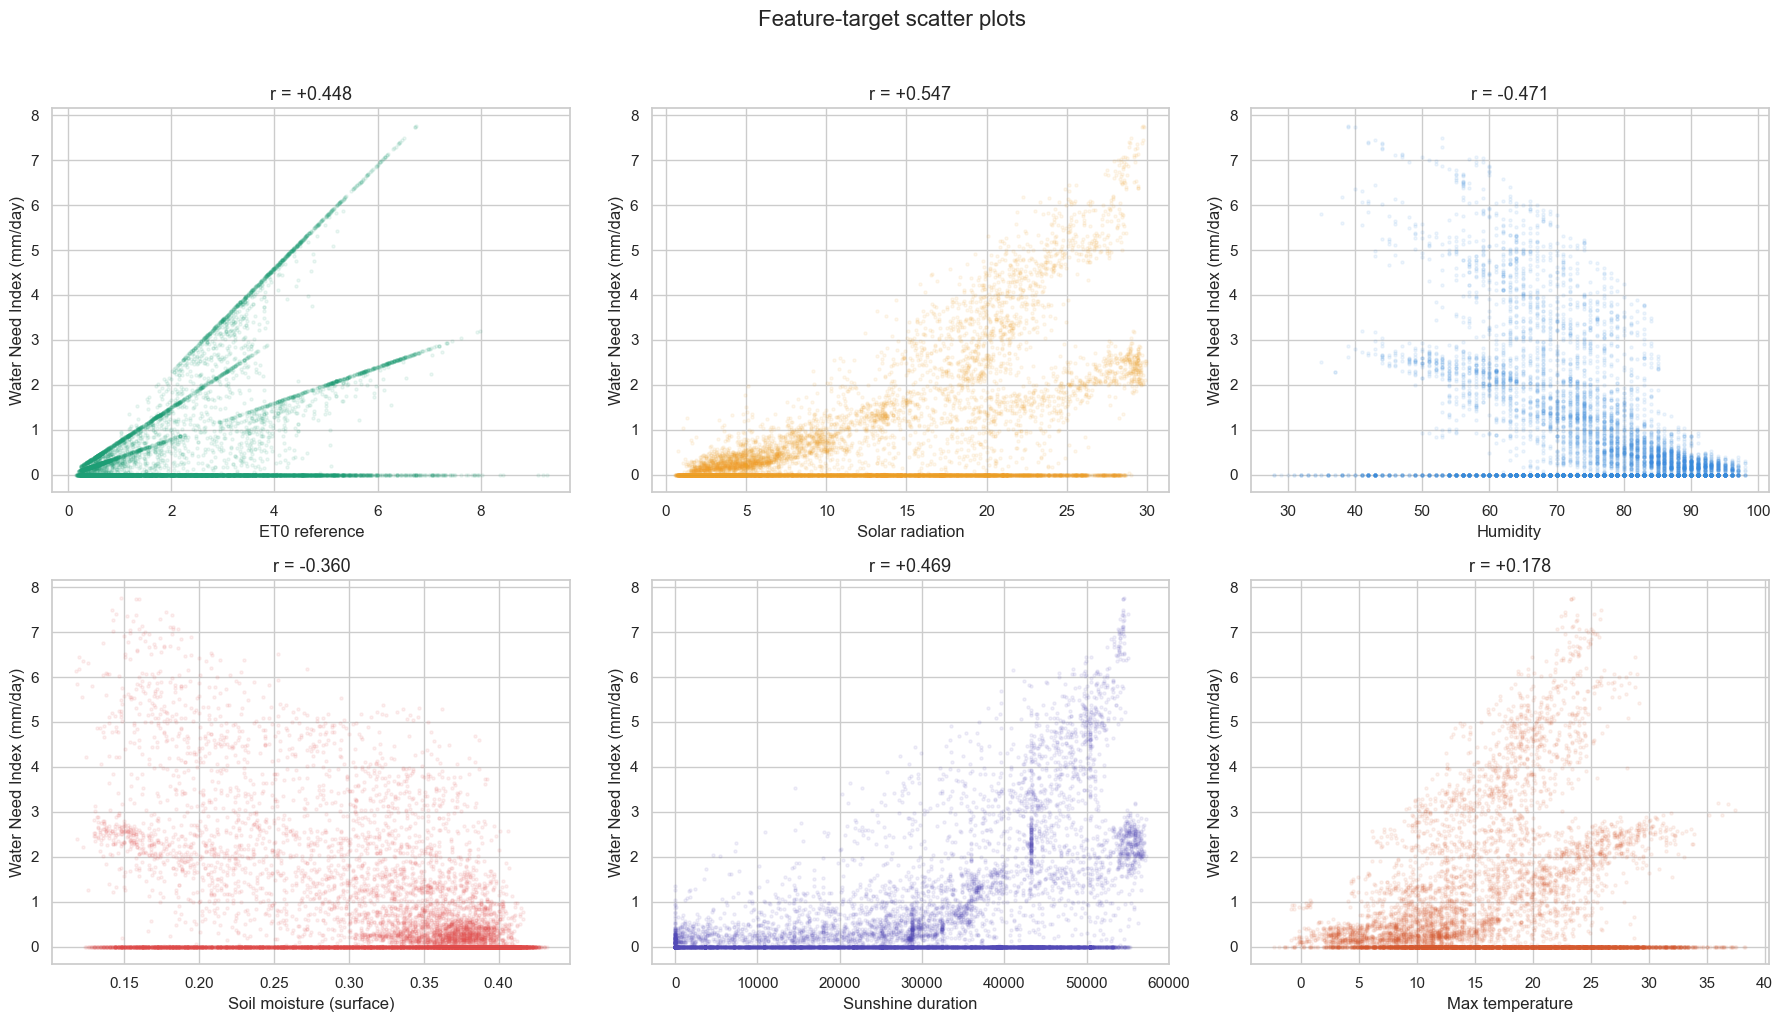

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pairs = [
    ('et0_fao_evapotranspiration', COLORS['primary'], 'ET0 reference'),
    ('shortwave_radiation_sum', COLORS['warning'], 'Solar radiation'),
    ('relative_humidity_2m_mean', COLORS['secondary'], 'Humidity'),
    ('soil_moisture_0_to_7cm_mean', COLORS['danger'], 'Soil moisture (surface)'),
    ('sunshine_duration', COLORS['purple'], 'Sunshine duration'),
    ('temperature_2m_max', COLORS['coral'], 'Max temperature'),
]

for ax, (col, color, label) in zip(axes.flat, pairs):
    corr_val = df[col].corr(df['water_need_index'])
    ax.scatter(df[col], df['water_need_index'], alpha=0.08, s=5, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('Water Need Index (mm/day)')
    ax.set_title(f'r = {corr_val:+.3f}', fontsize=13)

plt.suptitle('Feature-target scatter plots', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/05_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Notable patterns:**
- **ET0 vs WNI**: Distinct fan lines corresponding to different Kc values (growth stages).
- **Humidity**: Days above 80% almost never require irrigation.
- **Soil moisture**: Wet soil (>0.35) rarely coincides with high water need.
- **Temperature**: Weaker direct correlation because temperature alone does not determine water need — the combination with growth stage and humidity matters.

## 8. Spatial analysis: comparing locations

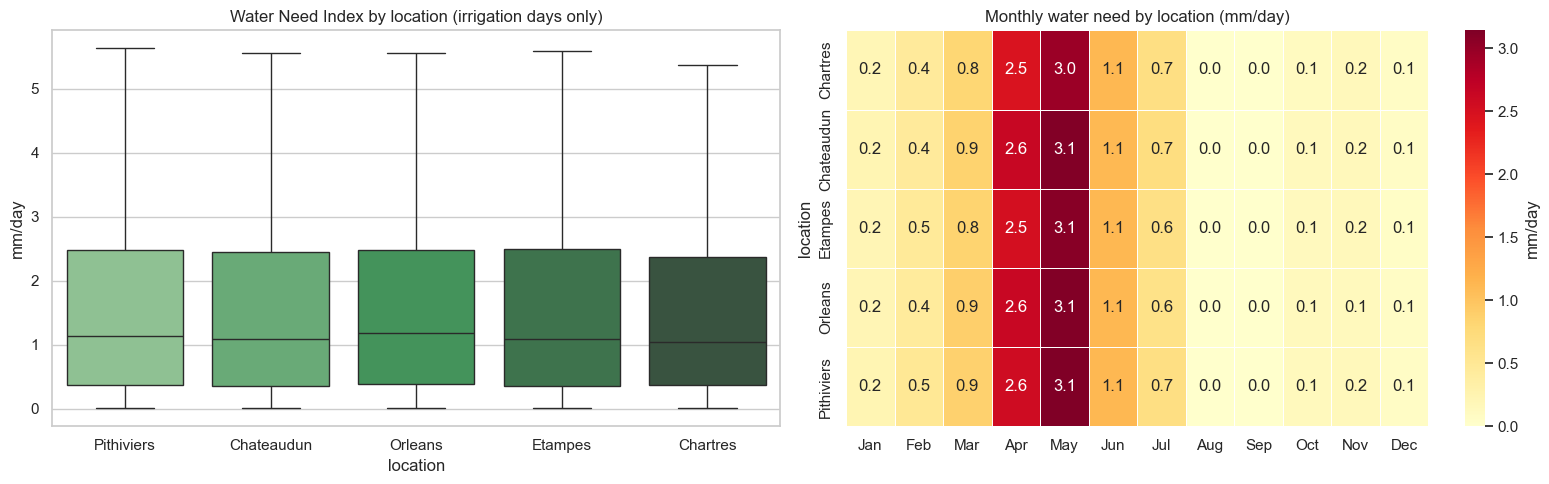

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_order = df.groupby('location')['water_need_index'].mean().sort_values(ascending=False).index
sns.boxplot(data=df[df['water_need_index'] > 0], x='location', y='water_need_index',
            order=loc_order, palette='Greens_d', ax=axes[0], showfliers=False)
axes[0].set_title('Water Need Index by location (irrigation days only)')
axes[0].set_ylabel('mm/day')

pivot = df.groupby(['location', df['date'].dt.month])['water_need_index'].mean().unstack()
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'mm/day'})
axes[1].set_title('Monthly water need by location (mm/day)')

plt.tight_layout()
plt.savefig('../reports/figures/06_spatial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Spatial observations:**
- All 5 locations show very similar patterns — expected since they are within ~50 km in the same Beauce region.
- For the MVP, location is not a strong differentiator. In production with wider geography, it would become important.

## 9. Data leakage check

In [12]:
leakage_features = ['etc_mm', 'effective_rainfall_mm', 'kc', 'irrigation_needed']

print('FEATURES TO EXCLUDE (data leakage risk):')
print('=' * 60)
reason = {
    'etc_mm': 'Directly used in WNI formula (ETc = ET0 x Kc)',
    'effective_rainfall_mm': 'Directly used in WNI formula',
    'kc': 'Derived from growth_stage (use growth_stage instead)',
    'irrigation_needed': 'Binary version of target itself',
}
for feat in leakage_features:
    corr_val = df[feat].corr(df['water_need_index'])
    print(f'  {feat:30s} r={corr_val:+.3f} -- {reason[feat]}')

print()
print('SAFE FEATURES FOR MODELING:')
print('=' * 60)
safe = [
    'temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum',
    'et0_fao_evapotranspiration', 'wind_speed_10m_max',
    'soil_moisture_0_to_7cm_mean', 'growth_stage', 'location',
]
for f in safe:
    print(f'  {f}')

FEATURES TO EXCLUDE (data leakage risk):
  etc_mm                         r=+0.904 -- Directly used in WNI formula (ETc = ET0 x Kc)
  effective_rainfall_mm          r=-0.263 -- Directly used in WNI formula
  kc                             r=+0.583 -- Derived from growth_stage (use growth_stage instead)
  irrigation_needed              r=+0.769 -- Binary version of target itself

SAFE FEATURES FOR MODELING:
  temperature_2m_mean
  relative_humidity_2m_mean
  precipitation_sum
  et0_fao_evapotranspiration
  wind_speed_10m_max
  soil_moisture_0_to_7cm_mean
  growth_stage
  location


**Data leakage prevention:**

Several columns are derived from the target formula — using them as features would give the model the answer:
- `etc_mm` (r=+0.90): This IS ETc = ET0 x Kc, most of the target formula.
- `effective_rainfall_mm`: The other half of the formula.
- `kc`: The crop coefficient. But `growth_stage` is safe (real-world observable).
- `irrigation_needed`: Binary version of the target.

**These four columns must be excluded from model features.**

## 10. Summary: preprocessing decisions for modeling

### Feature selection (reduce multicollinearity)
| Keep | Drop | Reason |
|------|------|--------|
| `temperature_2m_mean` | `temperature_2m_max`, `temperature_2m_min` | r=0.96-0.98 |
| `et0_fao_evapotranspiration` | `shortwave_radiation_sum`, `sunshine_duration` | r=0.90-0.95 |
| `soil_moisture_0_to_7cm_mean` | `soil_moisture_7_to_28cm_mean`, `..._28_to_100cm_mean` | r=0.83-0.93 |
| `precipitation_sum` | `rain_sum` | Nearly identical |

### Encoding
- `growth_stage`: ordinal (initial=1, development=2, mid_season=3, late_season=4, fallow=0)
- `location`: drop for MVP (minimal spatial variation) or one-hot

### Target strategy (zero-inflated distribution)
- **Stage 1 — Classification**: predict whether irrigation is needed (binary)
- **Stage 2 — Regression**: predict how much (mm/day) for irrigation days only

### Features to exclude (data leakage)
- `etc_mm`, `effective_rainfall_mm`, `kc`, `irrigation_needed`

### Final feature set
```
temperature_2m_mean, relative_humidity_2m_mean, precipitation_sum,
et0_fao_evapotranspiration, wind_speed_10m_max, soil_moisture_0_to_7cm_mean,
growth_stage (encoded)
```
**7 clean, independent, physically meaningful features.**